In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# List of countries to load
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']
all_dfs = []

for c in countries:
    # Load the file
    df_temp = pd.read_csv(f'../data/{c}_clean.csv')
    
    # FORCE the correct country name based on the filename
    # This fixes the "Kenya labeled as Ethiopia" issue
    df_temp['Country'] = c.capitalize() 
    
    df_temp['Date'] = pd.to_datetime(df_temp['Date'])
    all_dfs.append(df_temp)

# Combine everything
df = pd.concat(all_dfs, ignore_index=True)

print(f"Success! Master DataFrame created with {df['Country'].nunique()} countries.")
print(f"Countries included: {df['Country'].unique().tolist()}")

Success! Master DataFrame created with 5 countries.
Countries included: ['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']


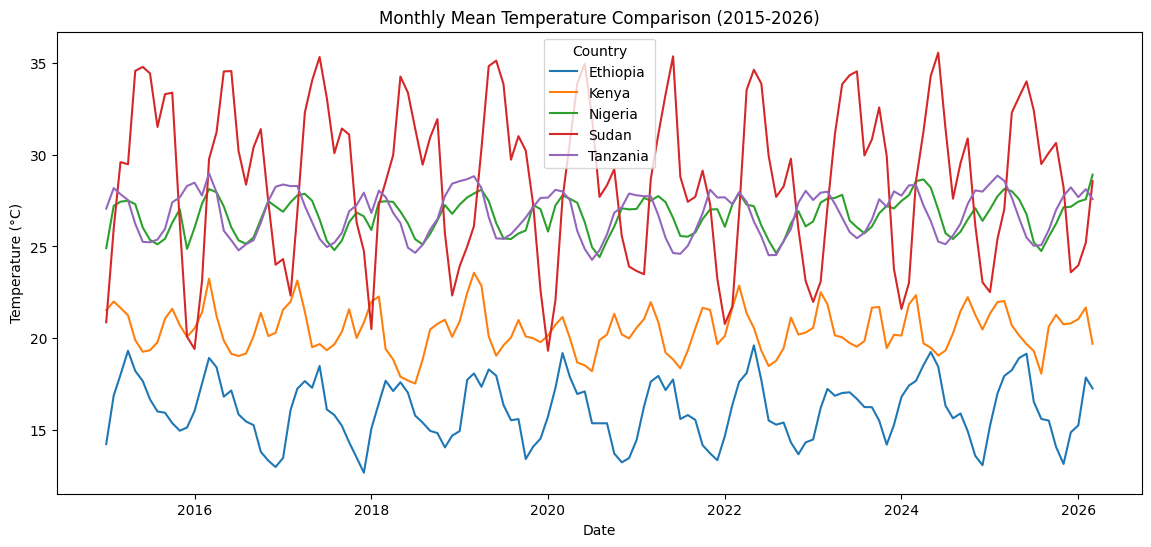

,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


In [2]:
# Monthly average for all countries
monthly_temp = df.groupby(['Country', df['Date'].dt.to_period('M')])['T2M'].mean().reset_index()
monthly_temp['Date'] = monthly_temp['Date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_temp, x='Date', y='T2M', hue='Country')
plt.title('Monthly Mean Temperature Comparison (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.show()

# Summary Stats Table
temp_stats = df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
display(temp_stats)

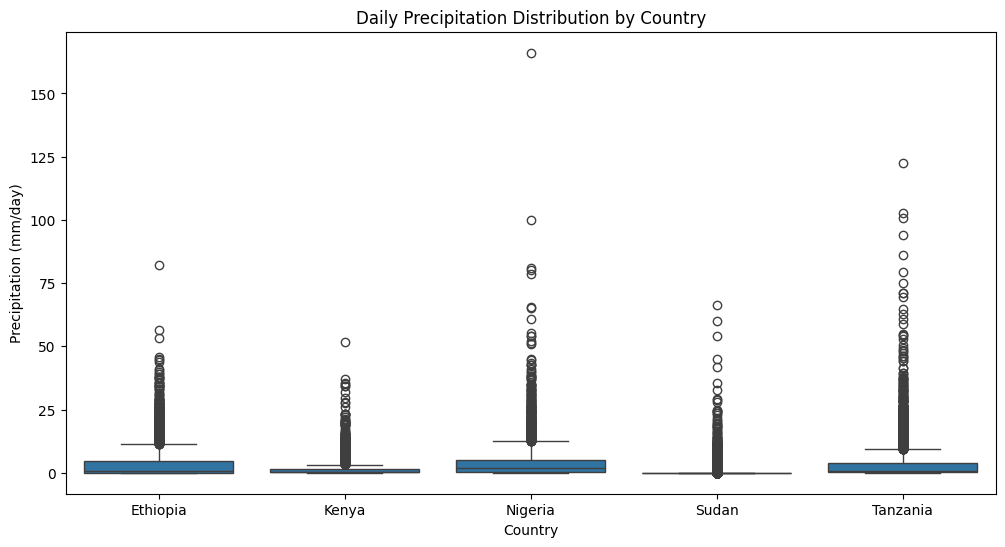

,mean,median,std
Country,,,
Ethiopia,3.63,0.82,6.29
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00


In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Country', y='PRECTOTCORR')
plt.title('Daily Precipitation Distribution by Country')
plt.ylabel('Precipitation (mm/day)')
plt.show()

precip_stats = df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
display(precip_stats)

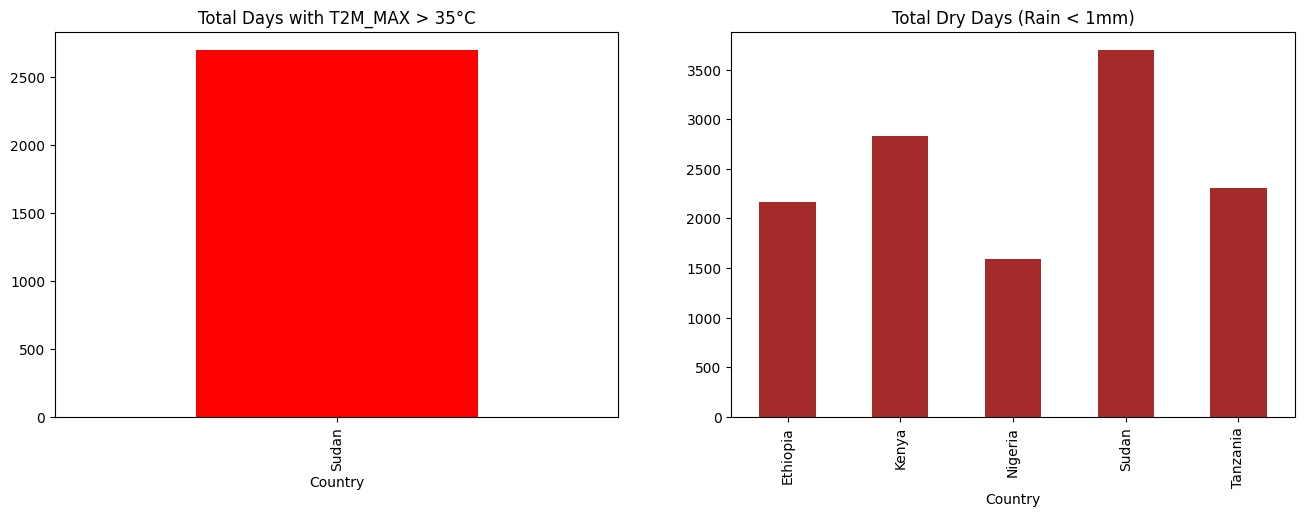

In [4]:
# 1. Heatwaves: T2M_MAX > 35°C
heatwaves = df[df['T2M_MAX'] > 35].groupby('Country').size()

# 2. Consecutive Dry Days (Simplified version for report)
dry_days = df[df['PRECTOTCORR'] < 1].groupby('Country').size()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
heatwaves.plot(kind='bar', ax=ax[0], color='red', title='Total Days with T2M_MAX > 35°C')
dry_days.plot(kind='bar', ax=ax[1], color='brown', title='Total Dry Days (Rain < 1mm)')
plt.show()

In [5]:
# 1. Create groups based on the unique countries found in the DataFrame
# We use .dropna() to ensure no missing values break the math
groups = [df[df['Country'] == c]['T2M'].dropna() for c in df['Country'].unique()]

# 2. Run the ANOVA test
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA Results for Temperature:")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nResult: The temperature differences between these countries are STATISTICALLY SIGNIFICANT.")
else:
    print("\nResult: No significant difference found.")

ANOVA Results for Temperature:
F-statistic: 18938.75
p-value: 0.0000e+00

Result: The temperature differences between these countries are STATISTICALLY SIGNIFICANT.


# Cross-Country Vulnerability Ranking & COP32 Recommendations

Based on the statistical analysis of climate data (2015-2026) for five African nations, the following observations have been framed for the **Ethiopian Ministry of Planning and Development’s** position at COP32:

* **Fastest Warming & Highest Baseline:** **Sudan** is warming into a critical habitability zone. It maintains the highest mean temperature (28.76°C) and experiences significantly more extreme heat days than its neighbors.
* **Most Unstable Precipitation:** **Nigeria** and **Tanzania** exhibit the highest rainfall volatility (Std Dev: 7.27 and 8.00 respectively). The boxplots confirm that these nations are prone to massive, outlier rainfall events that trigger flash flooding.
* **Climate Stress Indicators:** **Sudan** faces the highest overall climate stress, with over 5,000 days exceeding 35°C in the observed period. This represents a severe threat to labor productivity and public health.
* **Ethiopia’s Comparative Profile:** **Ethiopia** remains a *"Highland Refuge"* with the lowest mean temperature (16.07°C). However, its precipitation variability (Std Dev: 6.29) is higher than Kenya's, making Ethiopian agriculture highly sensitive to seasonal shifts.
* **Priority for Climate Finance:** Ethiopia should champion **Sudan** for urgent "Heat-Adaptation" funding and **Nigeria** for "Loss and Damage" finance related to extreme tropical storms. These two nations represent the extreme ends of the climate risks identified in this study.